In [1]:
%load_ext autoreload
%autoreload 2

# Пример инференса DLT модели (Ромашки 2.5/3.0) через FMLib

In [2]:
import pyarrow as pa
import torch
from torch.nn.attention import SDPBackend, sdpa_kernel
from tqdm.autonotebook import tqdm

from fmlib.data.io import ParquetDataset
from fmlib.data.io.writer import PartitionedParquetWriter
from fmlib.utils.loading import load_config, load_inference_pipeline

## Создание `ParquetDataset`
### Необходим для чтения файла по заданной структуре в метаданных. Позволяет загрузить датасет в оперативную память частями, а не полностью

In [3]:
model_folder = "configs/inference/dlt_embedding"
device = torch.device("cuda:0")

_, metadata = load_config(model_folder, config_file="parquet_metadata.yaml")

In [4]:
dataloader = ParquetDataset(
    source="/home/datalab/nfs/romashka_data",
    metadata=metadata,
    partition_size=4096,
    batch_size=64,
    device=device,
)

### Получение батча

In [5]:
batch = next(iter(dataloader))

## Загрузим объекты класса `InferencePipeline`
#### Класс `InferencePipeline` является наследником `torch.nn.Module`. Поэтому вы свободно можете применять `torch.compile` к нему

In [6]:
embedding_pipeline = load_inference_pipeline("configs/inference/dlt_embedding").eval().to(device=device)
heads_pipeline = load_inference_pipeline("configs/inference/dlt_heads").eval().to(device=device)

In [7]:
torch._dynamo.config.capture_scalar_outputs = True
embedding_pipeline = torch.compile(embedding_pipeline, dynamic=True)
heads_pipeline = torch.compile(heads_pipeline, dynamic=True)

In [8]:
with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.bfloat16), sdpa_kernel([SDPBackend.EFFICIENT_ATTENTION]):
    (transformed_batch,), (embedding_outputs,) = embedding_pipeline(batch)
    _, (heads_outputs,) = heads_pipeline(embedding_outputs)

## Пример запуска полного цикла инференса и побатчевая запись результата в `parquet`

In [9]:
import tempfile

directory = tempfile.TemporaryDirectory()

In [10]:
writer = PartitionedParquetWriter(base_path=f"{directory.name}/result", write_every_n_batch=8)

In [11]:
def handle_outputs(batch, outputs):
    result = {"epk_id": batch["epk_id"].long()}
    for key, value in outputs.items():
        result[key] = torch.nn.functional.softmax(value.float(), dim=-1)[:, -1]
    return result

## Цикл инференса

In [12]:
with torch.no_grad(), sdpa_kernel([SDPBackend.EFFICIENT_ATTENTION]):
    for _, batch in enumerate(tqdm(dataloader)):
        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            (transformed,), (embedding_outputs,) = embedding_pipeline(batch)
            _, (heads_outputs,) = heads_pipeline(embedding_outputs)
        result = handle_outputs(transformed, heads_outputs)
        writer.write(result)

  0%|          | 0/8280 [00:00<?, ?it/s]

In [13]:
writer.close()
writer.base_path

'/tmp/tmpzc1t75dd/result'

### Визуализация скоров

#### Для запуска понадобится установка библиотеки `matplotlib`

In [14]:
data = pa.parquet.read_table(writer.base_path)

In [15]:
import matplotlib.pyplot as plt

  0%|          | 0/10 [00:00<?, ?it/s]

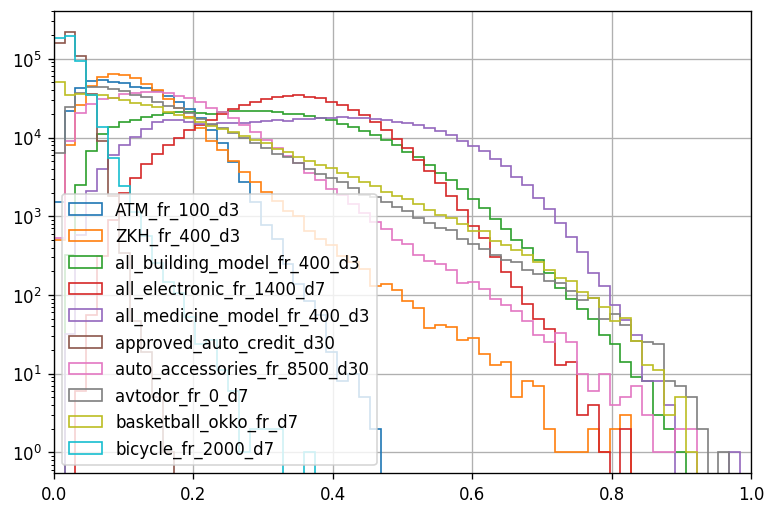

In [16]:
_ = plt.figure(figsize=(7.5, 5), dpi=120)
_ = plt.yscale("log", base=10)
_ = plt.xlim(0, 1)
_ = plt.grid()

for column in tqdm(sorted(set(data.column_names) - {"epk_id"})[:100:10]):
    curr_scores = torch.asarray(data.column(column).to_pylist(), dtype=torch.float32)

    _ = plt.hist(curr_scores, range=(0, 1), bins=64, histtype="step", label=column)

_ = plt.legend()
_ = plt.show()

In [17]:
import pyarrow.parquet as pq

In [18]:
!rm -rf /home/datalab/nfs/romashka_output

In [ ]:
pq.write_to_dataset(data, "/home/datalab/nfs/romashka_output")